In [1]:
%load_ext autoreload
%autoreload 2

import torch
import torch.nn as nn
import numpy as np

from torch.utils.data import TensorDataset, DataLoader
from torch.nn.utils import parameters_to_vector, vector_to_parameters
from tqdm import tqdm
from collections import defaultdict
import matplotlib.pyplot as plt

import sys
sys.path.append('..')

from sven.nn import SvenWrapper
from experiments.nn import MLP
from sven.opt import Sven

import copy
from pathlib import Path
import pandas as pd
import pickle

from experiments.experiment_code.experiment_utils import train_loop_standard, train_loop_svd, set_seed

device = torch.device('cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu'))
print(f"Using device: {device}")

Using device: mps


In [19]:
from experiments.datasets import RandomPolynomialDataset

polynomial = RandomPolynomialDataset(degree=4,num_vars=6,seed=57728)

In [20]:
set_seed(89929)

def make_mlp():
    return MLP(
        input_dim=6,
        hidden_dims=[16,16],
        output_dim=1
    )

mlp_base = make_mlp()
init_state = copy.deepcopy(mlp_base.state_dict())
del mlp_base # free memory

In [21]:
# training parameters
batch_size = 32
n_epoch = 20
LOADER_SEED = 82464

lr_adam = 1e-3
lr_sven = 0.5
k_sven = 32
rtol_sven = 1e-2

# Train with Adam

In [22]:
device = 'cpu'
model_adam = make_mlp()
model_adam.load_state_dict(init_state)
model_adam = model_adam.to(device)

optimizer = torch.optim.Adam(model_adam.parameters(), lr=lr_adam)
def loss_fn(pred,y):
    #y = F.one_hot(y, num_classes=len(digits)).to(pred)
    #return (pred - y).pow(2).sum(dim=1).mean()
    y = (pred - y).pow(2).sum(dim=1).mean()
    return y

train_loader = DataLoader(polynomial.train_dataset, batch_size=batch_size, shuffle=True, generator=torch.Generator().manual_seed(LOADER_SEED))
test_loader = DataLoader(polynomial.val_dataset, batch_size=256, shuffle=False)

model_adam, losses_adam = train_loop_standard(model_adam, optimizer, loss_fn, train_loader, test_loader, n_epoch, device, track_acc=True)

Using device cpu


100%|██████████| 20/20 [00:02<00:00,  8.73it/s]


# Train with Sven

In [23]:
if device == torch.device('mps'):
    device = torch.device('cpu')
model_sven = make_mlp()
model_sven.load_state_dict(init_state)
model_sven = model_sven.to(device)

def loss_fn(pred,y):
    #y = F.one_hot(y, num_classes=len(digits)).to(pred)
    #return (pred - y).pow(2).sum(dim=1)
    return (pred - y).pow(2).sum(dim=1)


model_sven = SvenWrapper(model_sven, loss_fn, device=device)
optimizer = Sven(model_sven,lr=lr_sven,k=k_sven,rtol=rtol_sven,track_svd_info=True,svd_mode='torch',use_rmsprop=False)

train_loader = DataLoader(polynomial.train_dataset, batch_size=batch_size, shuffle=True, generator=torch.Generator().manual_seed(LOADER_SEED))
test_loader = DataLoader(polynomial.val_dataset, batch_size=256, shuffle=False)

model_sven, losses_sven, optimizer = train_loop_svd(model_sven,optimizer,loss_fn,train_loader,test_loader,n_epoch,device,track_acc=True)
svd_info = optimizer.svd_info

100%|██████████| 20/20 [00:06<00:00,  3.28it/s]


# Train with Sven and $\kappa = 1$

In [24]:
if device == torch.device('mps'):
    device = torch.device('cpu')
model_sven_kappa1 = make_mlp()
model_sven_kappa1.load_state_dict(init_state)
model_sven_kappa1 = model_sven_kappa1.to(device)

def loss_fn(pred,y):
    #y = F.one_hot(y, num_classes=len(digits)).to(pred)
    #return (pred - y).pow(2).sum(dim=1)
    return (pred - y).pow(2).sum(dim=1)


model_sven_kappa1 = SvenWrapper(model_sven_kappa1, loss_fn, device=device, kappa=1.0)
optimizer = Sven(model_sven_kappa1,lr=lr_sven,k=k_sven,rtol=rtol_sven,track_svd_info=True,svd_mode='torch',use_rmsprop=False)

train_loader = DataLoader(polynomial.train_dataset, batch_size=batch_size, shuffle=True, generator=torch.Generator().manual_seed(LOADER_SEED))
test_loader = DataLoader(polynomial.val_dataset, batch_size=256, shuffle=False)

model_sven_kappa1, losses_sven_kappa1, optimizer = train_loop_svd(model_sven_kappa1,optimizer,loss_fn,train_loader,test_loader,n_epoch,device,track_acc=True)
svd_info = optimizer.svd_info

100%|██████████| 20/20 [00:06<00:00,  3.16it/s]


# Compare

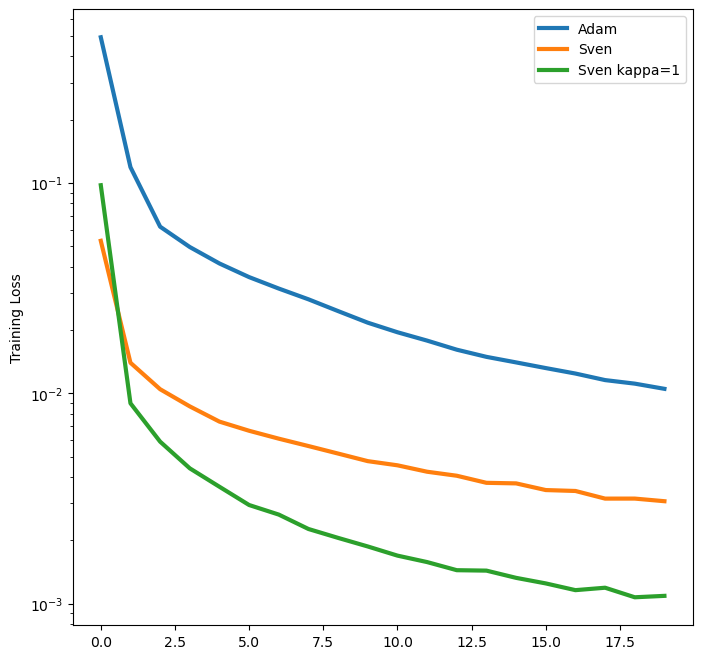

In [25]:
plt.figure(figsize=(8,8))
plt.plot(losses_adam['train'],label='Adam',lw=3)
plt.plot(losses_sven['train'],label='Sven',lw=3)
plt.plot(losses_sven_kappa1['train'],label='Sven kappa=1',lw=3)
plt.legend()
plt.ylabel("Training Loss")
plt.yscale('log')

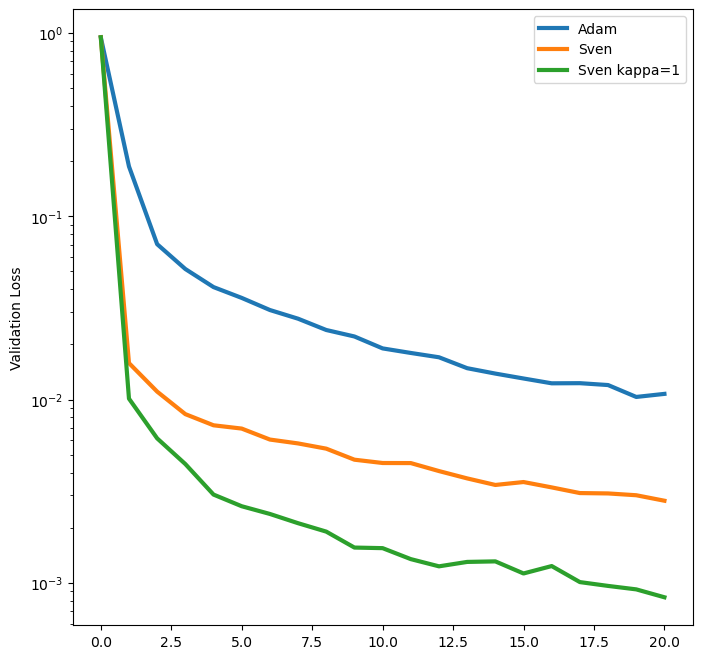

In [26]:
plt.figure(figsize=(8,8))
plt.plot(losses_adam['val'],label='Adam',lw=3)
plt.plot(losses_sven['val'],label='Sven',lw=3)
plt.plot(losses_sven_kappa1['val'],label='Sven kappa=1',lw=3)
plt.legend()
plt.ylabel("Validation Loss")
plt.yscale('log')